# 05. 확률 추정과 캘리브레이션

**이 프로젝트의 모델링 요구사항은 통상과 다르다.**

Kaggle 목표는 AUC이며 순위만 맞으면 되지만, 우리는 $p$ 를 기대비용 식에
**숫자로 직접** 넣는다:

$$\mathbb{E}[\text{cost}] = p \cdot C^{fraud} + (1-p) \cdot C^{legit}$$

실제 확률 2%인 거래에 모델이 0.2를 뱉으면 기대손실을 10배로 계산하고
잘못된 결정을 내린다. **순위가 완벽해도 정책은 틀린다.**

따라서 요구사항이 둘로 갈린다:
1. **변별력** — PR-AUC, Precision@k
2. **보정** — ECE, reliability diagram ← 통상 생략되나 여기선 필수

산출물: `data/processed/predictions.parquet`

In [2]:
import sys
from pathlib import Path

# src/ 를 import 경로에 추가 (uv pip install -e . 를 했다면 불필요)
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 운영체제별 폰트 설정 (예: 윈도우 맑은 고딕, 맥 애플고딕)
import matplotlib.font_manager as fm
import platform

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    # Colab의 경우 나눔고딕 설치 후 적용 필요
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from frauddetectionreport import config, data, splits, features, evaluate
from frauddetectionreport.config import TARGET, TIME_COL, AMOUNT_COL

feat = pd.read_parquet(config.FEATURES_PARQUET)
sp = splits.make_time_split(feat)
y = feat[TARGET].to_numpy()
amount = feat[AMOUNT_COL].to_numpy()

X_cols = features.model_columns(feat)
X = feat[X_cols]
print(f"{feat.shape[0]:,}건 × {len(X_cols)}개 피처")

Task was destroyed but it is pending!
task: <Task pending name='Task-219' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-220' coro=<Kernel.shell_main() running at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\fraudDetectionReport\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\fraudDetectionReport\.venv\Lib\site-packages\pyarrow\dataset.py:85: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from pyarrow._dataset_parquet import (  # noqa
Task was destroyed but it is pending!
task: <Task pending name='Task-220' coro=<Kernel.shell_main() running at C:\fraudDetectionReport\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


590,540건 × 465개 피처


## 1. 클래스 불균형 — 가중치를 쓰지 않는다

사기율 3.5%에 통상 `scale_pos_weight`나 오버샘플링을 쓴다.
본 연구의 기본 모델은 가중치를 쓰지 않되, 가중 모델도 별도로 보정한 뒤
변별력과 정책 비용을 비교해 선택한다.

**근거 1.** 가중치는 원시 출력 확률을 실제 빈도보다 위로 밀 수 있다.
따라서 가중 모델의 원시 확률을 기대비용 식에 바로 넣지 않고 독립적으로 보정한다.

**근거 2.** 불균형 보정의 목적인 '임계값 조정 효과'를 우리는
**비용 함수가 명시적으로** 수행한다. 모델 단에서 또 하면 이중 적용이다.

아래에서 이를 **실증**한다.

In [3]:
LGB_PARAMS = dict(
    objective="binary", learning_rate=0.03, num_leaves=127,
    min_child_samples=80, feature_fraction=0.6, bagging_fraction=0.8,
    bagging_freq=1, lambda_l2=1.0, verbose=-1,
    seed=config.RANDOM_SEED, n_jobs=-1,
)

def fit_lgb(params, tr_mask, va_mask=None, n_rounds=2000):
    ds_tr = lgb.Dataset(X[tr_mask], y[tr_mask])
    if va_mask is None:
        return lgb.train(params, ds_tr, num_boost_round=n_rounds)
    ds_va = lgb.Dataset(X[va_mask], y[va_mask], reference=ds_tr)
    return lgb.train(params, ds_tr, num_boost_round=n_rounds, valid_sets=[ds_va],
                     callbacks=[lgb.early_stopping(100, verbose=False),
                                lgb.log_evaluation(200)])

In [4]:
%%time
# train 내부의 마지막 시간 폴드에서 반복 수를 정한다. calib은 건드리지 않는다.
fit_tr, fit_va = splits.time_series_folds(feat, sp.train, n_folds=4)[-1]
pos_w = (y[sp.train] == 0).sum() / (y[sp.train] == 1).sum()
m_plain_es = fit_lgb(LGB_PARAMS, fit_tr, fit_va)
m_weighted_es = fit_lgb({**LGB_PARAMS, "scale_pos_weight": pos_w}, fit_tr, fit_va)

# 결정된 반복 수로 전체 train을 재학습한다.
m_plain = fit_lgb(LGB_PARAMS, sp.train, n_rounds=m_plain_es.best_iteration)
m_weighted = fit_lgb({**LGB_PARAMS, "scale_pos_weight": pos_w}, sp.train,
                     n_rounds=m_weighted_es.best_iteration)

print(f"\n선택 반복 수 — 가중치 없음 {m_plain_es.best_iteration}, 있음 {m_weighted_es.best_iteration}")

[200]	valid_0's binary_logloss: 0.0901565
[400]	valid_0's binary_logloss: 0.0892681

선택 반복 수 — 가중치 없음 353, 있음 3
CPU times: total: 31min 23s
Wall time: 7min 33s


In [5]:
p_plain = m_plain.predict(X[sp.calib])
p_weighted = m_weighted.predict(X[sp.calib])
y_calib = y[sp.calib]

cmp = pd.DataFrame([
    {"모델": "가중치 없음", **evaluate.model_report(y_calib, p_plain, k=500)},
    {"모델": "가중치 있음", **evaluate.model_report(y_calib, p_weighted, k=500)},
]).set_index("모델")
display(cmp.style.format("{:.4f}"))

,pr_auc,roc_auc,k,precision_at_k,recall_at_k,ece,brier
모델,,,,,,,
가중치 없음,0.6192,0.9308,500.0000,0.9220,0.1327,0.0051,0.0220
가중치 있음,0.4375,0.8789,500.0000,0.8480,0.1221,0.0470,0.0351


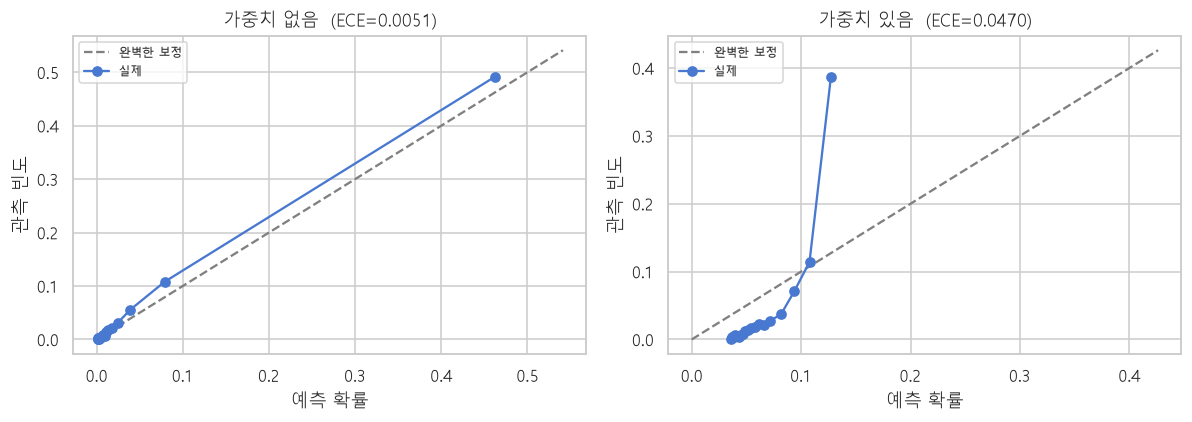

In [6]:
# reliability diagram 대조 — 이것이 가중치를 쓰지 않는 이유다
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (pr, name) in zip(axes, [(p_plain, "가중치 없음"), (p_weighted, "가중치 있음")]):
    t = evaluate.calibration_table(y_calib, pr, n_bins=20)
    ax.plot([0, t.observed.max()*1.1], [0, t.observed.max()*1.1], "--", c="gray", label="완벽한 보정")
    ax.plot(t.mean_pred, t.observed, "o-", label="실제")
    ax.set_xlabel("예측 확률"); ax.set_ylabel("관측 빈도")
    ax.set_title(f"{name}  (ECE={evaluate.calibration_error(y_calib, pr):.4f})")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> 가중치를 준 모델의 곡선이 대각선 **위로** 떠 있다면 원시 확률을 체계적으로
> 과대 예측한다는 뜻이다. 다만 독립 보정 후 성능까지 비교해야 모델 자체를 배제할 수 있다.
>
> 이 그림을 보고서 §3에 싣는다.

## 2. 대조군 — 로지스틱 회귀

성능 자랑이 아니라 **P1(규칙)과 짝을 이루는 비교 축**이다.
"모델 복잡도 상승이 총비용을 실제로 줄였는가"를 06에서 확인한다.

In [7]:
%%time
num_cols = [c for c in X_cols if X[c].dtype.kind in "fiub"][:80]  # 상위 80개만
lr = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1000, C=0.1, n_jobs=-1),
)
lr.fit(X.loc[sp.train, num_cols], y[sp.train])
p_lr = lr.predict_proba(X.loc[sp.calib, num_cols])[:, 1]

print(pd.Series(evaluate.model_report(y_calib, p_lr, k=500)).round(4))

C:\fraudDetectionReport\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


pr_auc              0.3291
roc_auc             0.8253
k                 500.0000
precision_at_k      0.8500
recall_at_k         0.1224
ece                 0.0152
brier               0.0315
dtype: float64
CPU times: total: 58.9 s
Wall time: 24.5 s


## 3. 캘리브레이션

- **isotonic** 우선. Platt(시그모이드)은 형태 가정이 있어 GBDT 출력의
  왜곡을 다 잡지 못한다. calib 구간이 10만 건 이상이므로 과적합 위험이 낮다.
- **보정 구간과 학습 구간이 겹치면 안 된다** → calib에서 fit, test에 적용

In [8]:
iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_plain, y_calib)
iso_weighted = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_weighted, y_calib)
iso_lr = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(p_lr, y_calib)

p_test_raw = m_plain.predict(X[sp.test])
p_test_cal = iso.predict(p_test_raw)
p_test_weighted_cal = iso_weighted.predict(m_weighted.predict(X[sp.test]))
p_test_lr_cal = iso_lr.predict(lr.predict_proba(X.loc[sp.test, num_cols])[:, 1])
y_test = y[sp.test]
amt_test = amount[sp.test]

rep = pd.DataFrame([
    {"단계": "보정 전", **evaluate.model_report(y_test, p_test_raw, k=500)},
    {"단계": "보정 후", **evaluate.model_report(y_test, p_test_cal, k=500)},
    {"단계": "가중 모델 보정 후", **evaluate.model_report(y_test, p_test_weighted_cal, k=500)},
]).set_index("단계")
display(rep.style.format("{:.4f}"))

,pr_auc,roc_auc,k,precision_at_k,recall_at_k,ece,brier
단계,,,,,,,
보정 전,0.5164,0.9046,500.0000,0.9420,0.1159,0.0041,0.0224
보정 후,0.5029,0.9044,500.0000,0.9480,0.1166,0.0042,0.0225
가중 모델 보정 후,0.3407,0.8521,500.0000,0.7740,0.0952,0.0054,0.0263


> **PR-AUC/ROC-AUC는 거의 변하지 않고 ECE와 Brier만 개선되는 것이 정상이다.**
> isotonic은 단조 변환이므로 순위를 바꾸지 않는다. 우리가 원하는 것이
> 정확히 그것 — 순위는 그대로 두고 **값만 바로잡는 것**이다.

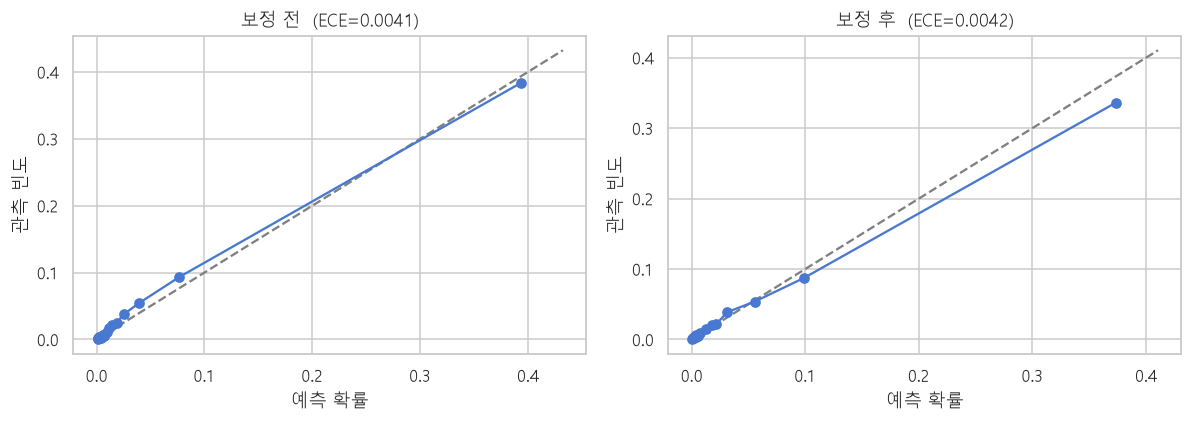

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (pr, name) in zip(axes, [(p_test_raw, "보정 전"), (p_test_cal, "보정 후")]):
    t = evaluate.calibration_table(y_test, pr, n_bins=20)
    lim = max(t.observed.max(), t.mean_pred.max()) * 1.1
    ax.plot([0, lim], [0, lim], "--", c="gray")
    ax.plot(t.mean_pred, t.observed, "o-")
    ax.set_xlabel("예측 확률"); ax.set_ylabel("관측 빈도")
    ax.set_title(f"{name}  (ECE={evaluate.calibration_error(y_test, pr):.4f})")
plt.tight_layout(); plt.show()

### 금액 구간별 보정 ← 반드시 확인

전체 ECE가 낮아도 **고액 구간에서 어긋나면 손실이 큰 쪽에서 정책이 틀린다.**
평균 하나로는 절대 보이지 않으므로 분리해서 본다.

In [10]:
for name, pr in [("보정 전", p_test_raw), ("보정 후", p_test_cal)]:
    print(f"\n=== {name} ===")
    display(evaluate.calibration_by_amount(y_test, pr, amt_test, n_groups=5)
            .style.format({"fraud_rate": "{:.3%}", "mean_pred": "{:.4f}", "ece": "{:.4f}"}))


=== 보정 전 ===


,amount_group,amount_range,n,fraud_rate,mean_pred,ece
0,0,0–36,21931,5.025%,0.0451,0.0053
1,1,36–58,21356,2.889%,0.0228,0.0066
2,2,58–100,26461,2.774%,0.0227,0.0058
3,3,100–160,24159,2.744%,0.0269,0.0034
4,4,160–5367,24201,3.917%,0.0418,0.0041



=== 보정 후 ===


,amount_group,amount_range,n,fraud_rate,mean_pred,ece
0,0,0–36,21931,5.025%,0.0491,0.0042
1,1,36–58,21356,2.889%,0.0255,0.0037
2,2,58–100,26461,2.774%,0.0257,0.0022
3,3,100–160,24159,2.744%,0.0311,0.0067
4,4,160–5367,24201,3.917%,0.0492,0.0104


## 4. 피처 중요도와 설명가능성

보고서 §3의 설명가능성 절. "왜 이 거래를 막았는가"에 답할 수 있어야 한다.

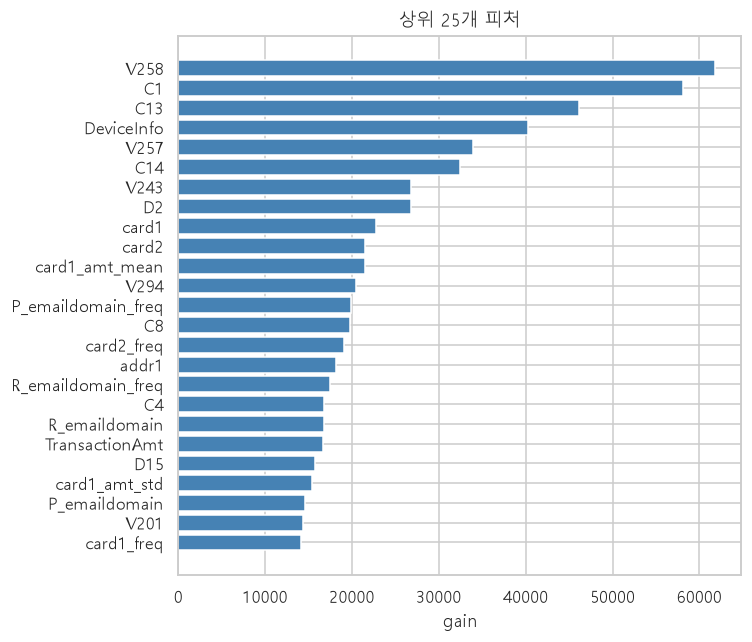

상위 25개 중 uid 파생: 0개


,feature,gain


In [11]:
imp = pd.DataFrame({
    "feature": m_plain.feature_name(),
    "gain": m_plain.feature_importance("gain"),
}).sort_values("gain", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(imp.feature[::-1], imp.gain[::-1], color="steelblue")
ax.set_xlabel("gain"); ax.set_title("상위 25개 피처")
plt.tight_layout(); plt.show()

# uid 파생 피처가 상위에 있는지 — 04의 소유자 추정이 실제로 기여했는가
uid_feats = imp[imp.feature.str.contains("uid")]
print(f"상위 25개 중 uid 파생: {len(uid_feats)}개")
display(uid_feats)

C:\fraudDetectionReport\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


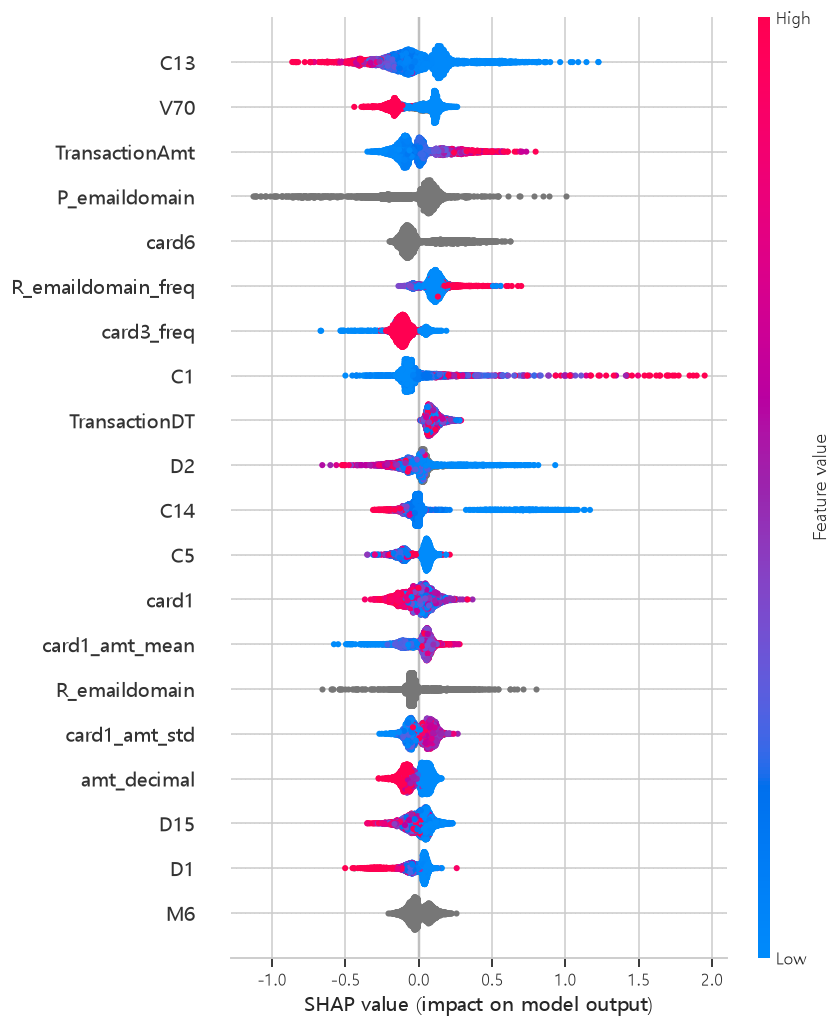

CPU times: total: 11min 46s
Wall time: 2min 24s


In [12]:
%%time
import shap

# 계산량이 크므로 표본에서
sample = X[sp.test].sample(n=min(5000, sp.test.sum()), random_state=config.RANDOM_SEED)
explainer = shap.TreeExplainer(m_plain)
sv = explainer.shap_values(sample)

shap.summary_plot(sv, sample, max_display=20, show=False)
plt.tight_layout(); plt.show()

## 5. 저장 — 06의 입력

06은 저장된 확률만 읽어 정책을 갈아끼운다.
**모델 재학습 없이 파라미터를 바꿔가며 빠르게 반복**할 수 있다.
민감도 분석을 여러 번 돌릴 것이므로 이 분리가 실질적으로 중요하다.

In [13]:
test_a, test_b = splits.split_test_halves(feat, sp.test)

pred = pd.DataFrame({
    "TransactionID": feat.loc[sp.test, "TransactionID"].to_numpy(),
    "TransactionDT": feat.loc[sp.test, TIME_COL].to_numpy(),
    "p_raw": p_test_raw,
    "p": p_test_cal,                      # 보정된 확률 — 정책이 쓸 값
    "p_weighted": p_test_weighted_cal,
    "p_lr": p_test_lr_cal,
    "amount": amt_test,
    "is_fraud": y_test,
    "half": np.where(test_a[sp.test], "a_select", "b_confirm"),
})
for col in ["ProductCD", "DeviceType", "card4", "card6"]:
    if col in feat.columns:
        pred[col] = feat.loc[sp.test, col].astype(str).to_numpy()

pred.to_parquet(config.PREDICTIONS_PARQUET, index=False)
print(f"저장: {config.PREDICTIONS_PARQUET}  {pred.shape}")
display(pred.head())

저장: C:\fraudDetectionReport\data\processed\predictions.parquet  (118108, 13)


,TransactionID,TransactionDT,p_raw,p,p_weighted,p_lr,amount,is_fraud,half,ProductCD,DeviceType,card4,card6
0,3459432,12192900,0.016893,0.021429,0.021299,0.123112,33.261002,1,a_select,C,desktop,visa,debit
1,3459433,12192911,0.001208,0.001025,0.021299,0.016589,52.811001,0,a_select,C,mobile,visa,debit
2,3459434,12192913,0.189505,0.242424,0.194953,0.187279,136.955994,0,a_select,C,desktop,visa,debit
3,3459435,12193040,0.339483,0.374269,0.072792,0.222222,136.955994,0,a_select,C,desktop,visa,debit
4,3459436,12193199,0.004210,0.003245,0.021299,0.040352,25.000000,0,a_select,H,desktop,visa,debit


## 요약

- 가중치 유/무 모델을 각각 독립 보정해 비교
- isotonic 보정으로 순위는 유지하고 확률값만 교정
- 금액 구간별 보정 확인 (전체 ECE로는 안 보이는 문제)
- `predictions.parquet` 저장 → 06에서 모델 없이 정책 실험
- 다음: `06_policy_comparison` — **본론**